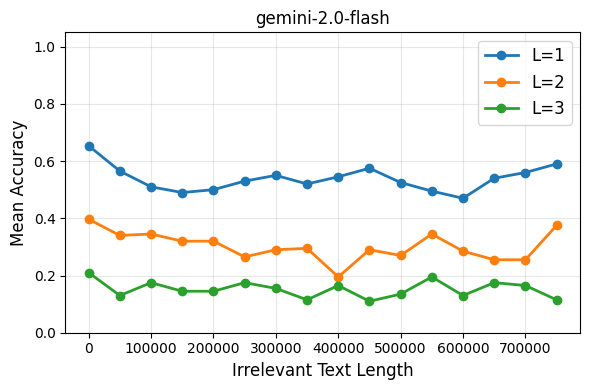

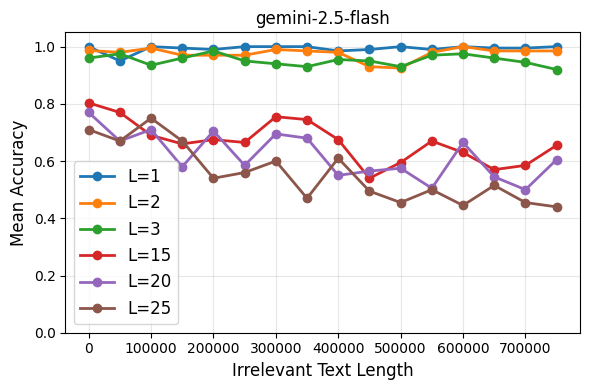

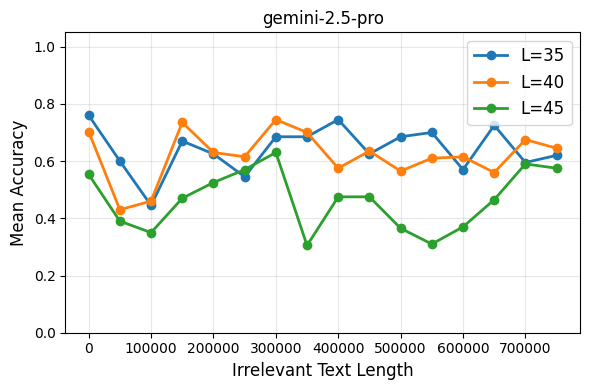

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

model_config = {
    "gemini-2.0-flash": [1, 2, 3],
    "gemini-2.5-flash": [1, 2, 3, 15, 20, 25],
    "gemini-2.5-pro": [35, 40, 45],
}

record_file = 'records'

for model_name, N_values_to_plot in model_config.items():
    # Load CSV file
    csv_path = f'/Users/hwanda/Desktop/EdenCode/projects/PyCliffordMCP/dev/pauli_string_multiplication/direct_multiplication/{record_file}/{model_name}/accuracy_summary.csv'
    
    try:
        df = pd.read_csv(csv_path)
        
        # Filter to temperature=0.0 only
        df = df[df['temperature'] == 0.0]
        
        # Create plot
        plt.figure(figsize=(6, 4))
        
        # Plot only the specified N values
        for N in N_values_to_plot:
            # Filter data for this N value
            n_data = df[df['N'] == N]
            
            if len(n_data) > 0:  # Only plot if data exists
                # Group by L_irr and calculate mean accuracy
                grouped = n_data.groupby('L_irr')['accuracy'].mean()
                
                # Plot
                plt.plot(grouped.index, grouped.values, marker='o', label=f'L={N}', linewidth=2)
            else:
                print(f"Warning: No data found for N={N} in {model_name}")
        
        plt.xlabel('Irrelevant Text Length', fontsize=12)
        plt.ylabel('Mean Accuracy', fontsize=12)
        plt.title(f'{model_name}', fontsize=12)
        plt.legend(fontsize=12)
        plt.grid(True, alpha=0.3)
        plt.ylim(0, 1.05)
        plt.tight_layout()
        plt.show()
        
    except FileNotFoundError:
        print(f"❌ File not found: {csv_path}")
    except Exception as e:
        print(f"❌ Error loading {model_name}: {e}")

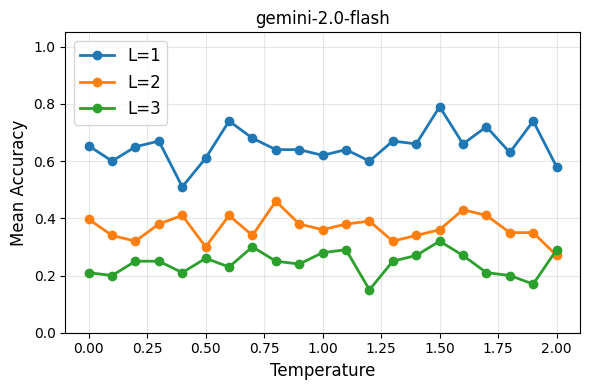

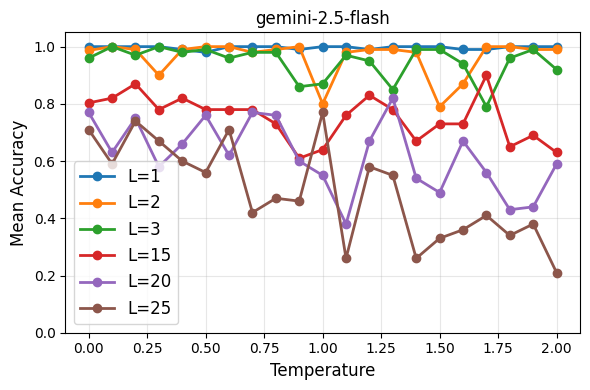

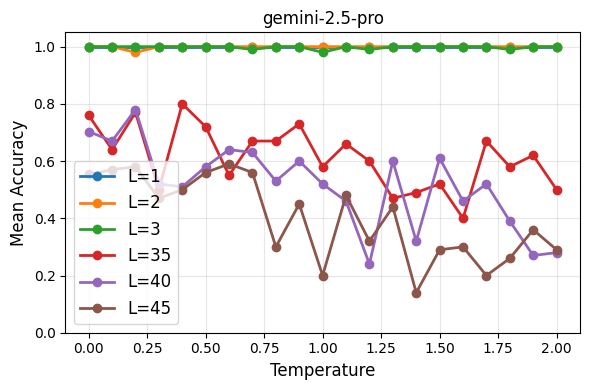

In [17]:
import pandas as pd
import matplotlib.pyplot as plt

model_config = {
    "gemini-2.0-flash": [1,2,3],
    "gemini-2.5-flash": [1, 2, 3, 15, 20, 25],
    "gemini-2.5-pro": [1, 2, 3, 35, 40, 45],
}

record_file = 'records'

for model_name, N_values_to_plot in model_config.items():
    # Load CSV file
    csv_path = f'/Users/hwanda/Desktop/EdenCode/projects/PyCliffordMCP/dev/pauli_string_multiplication/direct_multiplication/{record_file}/{model_name}/accuracy_summary.csv'
    
    try:
        df = pd.read_csv(csv_path)
        
        df = df[df['L_irr'] == 0]
        
        # Create plot
        plt.figure(figsize=(6, 4))
        
        # Plot only the specified N values
        for N in N_values_to_plot:
            # Filter data for this N value
            n_data = df[df['N'] == N]
            
            if len(n_data) > 0:  # Only plot if data exists
                # Group by temperature and calculate mean accuracy
                grouped = n_data.groupby('temperature')['accuracy'].mean()
                
                # Plot
                plt.plot(grouped.index, grouped.values, marker='o', label=f'L={N}', linewidth=2)
            else:
                print(f"Warning: No data found for L={N} in {model_name}")
        
        plt.xlabel('Temperature', fontsize=12)
        plt.ylabel('Mean Accuracy', fontsize=12)
        plt.title(f'{model_name}', fontsize=12)
        plt.legend(fontsize=12)
        plt.grid(True, alpha=0.3)
        plt.ylim(0, 1.05)
        plt.tight_layout()
        plt.show()
        
    except FileNotFoundError:
        print(f"❌ File not found: {csv_path}")
    except Exception as e:
        print(f"❌ Error loading {model_name}: {e}")

/var/folders/jp/m4qjzd2957d96wtmydjy3z_m0000gn/T/ipykernel_11443/3943848437.py:23: RuntimeWarning: divide by zero encountered in log
  ax.plot(grouped.index, np.log(grouped.values), marker='o', color='blue',


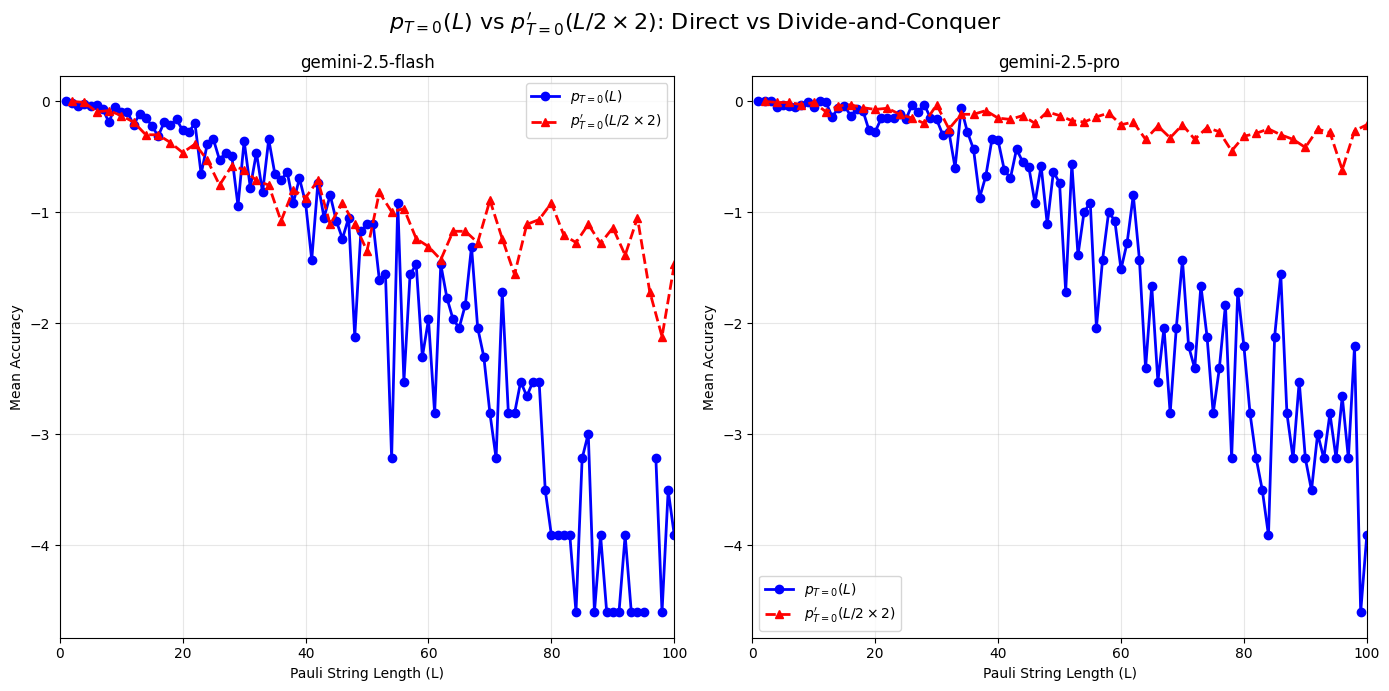

In [45]:
# Individual plots for each model in subplots
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

models = ["gemini-2.5-flash", "gemini-2.5-pro"]

# Create subplots
fig, axes = plt.subplots(1, len(models), figsize=(14, 7))
fig.suptitle(r'$p_{T=0}(L)$ vs $p^{\prime}_{T=0}(L/2 \times 2)$: Direct vs Divide-and-Conquer', fontsize=16)

for idx, model in enumerate(models):
    ax = axes[idx]
    
    # === DIRECT MULTIPLICATION DATA ===
    try:
        csv_path = f'/Users/hwanda/Desktop/EdenCode/projects/PyCliffordMCP/dev/pauli_string_multiplication/direct_multiplication/records/{model}/accuracy_summary.csv'
        df = pd.read_csv(csv_path)
        df_clean = df[(df['temperature'] == 0.0) & (df['L_irr'] == 0)]
        grouped = df_clean.groupby('N')['accuracy'].mean()
        
        if not grouped.empty:
            ax.plot(grouped.index, np.log(grouped.values), marker='o', color='blue', 
                   label=r'$p_{T=0}(L)$', linewidth=2, linestyle='-')
            
    except FileNotFoundError:
        pass

    # === DIVIDE-AND-CONQUER DATA ===
    try:
        csv_path = f'/Users/hwanda/Desktop/EdenCode/projects/PyCliffordMCP/dev/pauli_string_multiplication/divide_and_conquer/records/{model}/accuracy_summary.csv'
        df = pd.read_csv(csv_path)
        df_clean = df[(df['temperature'] == 0.0) & 
                        (df['workflow_success'] == True) & 
                        (df['chunk_size'] == df['N'] // 2)]
        grouped = df_clean.groupby('N')['accuracy'].mean()
        
        if not grouped.empty:
            ax.plot(grouped.index, np.log(grouped.values), marker='^', color='red', 
                    label=r'$p^{\prime}_{T=0}(L/2 \times 2)$', linewidth=2, linestyle='--')
            
    except FileNotFoundError:
        pass
    
    # Formatting for each subplot
    ax.set_xlabel('Pauli String Length (L)')
    ax.set_ylabel('Mean Accuracy')
    ax.set_title(f'{model}')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_xlim(0, 100)
    #ax.set_ylim(-0.05, 1.05)

plt.tight_layout()
plt.show()


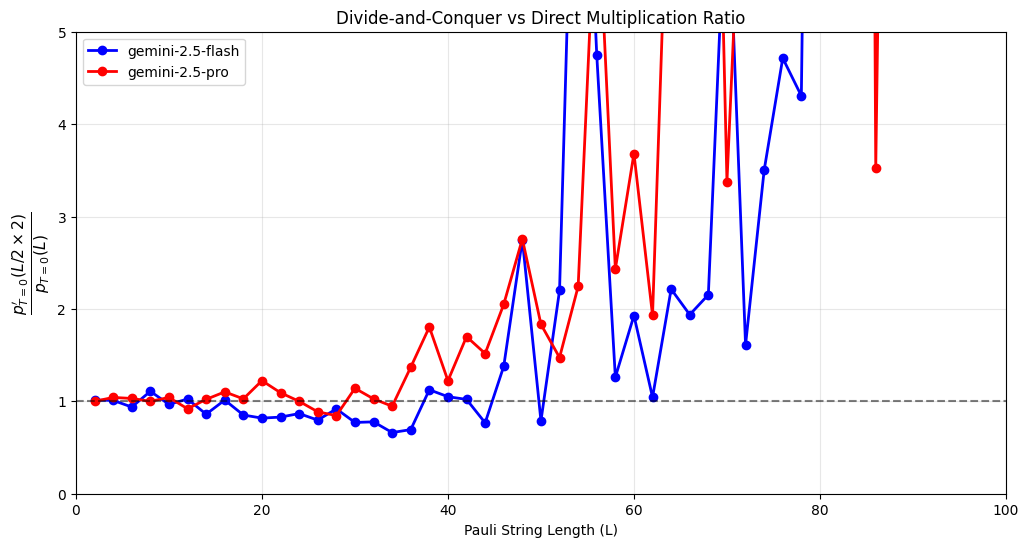

In [39]:
# Plot ratio between direct and divide-and-conquer
import pandas as pd
import matplotlib.pyplot as plt

models = ["gemini-2.5-flash", "gemini-2.5-pro"]
colors = ["blue", "red"]

plt.figure(figsize=(12, 6))

for model, color in zip(models, colors):
    # Load direct data
    direct_path = f'/Users/hwanda/Desktop/EdenCode/projects/PyCliffordMCP/dev/pauli_string_multiplication/direct_multiplication/records/{model}/accuracy_summary.csv'
    df_direct = pd.read_csv(direct_path)
    direct_clean = df_direct[(df_direct['temperature'] == 0.0) & (df_direct['L_irr'] == 0)]
    direct_grouped = direct_clean.groupby('N')['accuracy'].mean()
    
    # Load D&C data
    dc_path = f'/Users/hwanda/Desktop/EdenCode/projects/PyCliffordMCP/dev/pauli_string_multiplication/divide_and_conquer/records/{model}/accuracy_summary.csv'
    df_dc = pd.read_csv(dc_path)
    dc_clean = df_dc[(df_dc['temperature'] == 0.0) & 
                     (df_dc['workflow_success'] == True) & 
                     (df_dc['chunk_size'] == df_dc['N'] // 2)]
    dc_grouped = dc_clean.groupby('N')['accuracy'].mean()
    
    # Calculate ratio (D&C / Direct)
    common_N = direct_grouped.index.intersection(dc_grouped.index)
    ratio = dc_grouped[common_N] / direct_grouped[common_N]
    
    plt.plot(common_N, ratio, marker='o', color=color, label=model, linewidth=2)

plt.xlabel('Pauli String Length (L)')
plt.ylabel(r'$\frac{p^{\prime}_{T=0}(L/2 \times 2)}{p_{T=0}(L)}$', fontsize=16)
plt.title('Divide-and-Conquer vs Direct Multiplication Ratio')
plt.legend()
plt.grid(True, alpha=0.3)
plt.axhline(y=1, color='black', linestyle='--', alpha=0.5, label='Equal Performance')
plt.xlim(0, 100)
plt.ylim(0, 5)
plt.show()
